In [259]:
#download liberieres

In [260]:
import numpy as np
import pandas as pd

In [261]:
#download and read the dataset

In [262]:
df = pd.read_csv("MainCall.csv", sep=",", names=["label","message"])


In [263]:
df.sample(5)


,label,message
4793,normal,alright. Thanks for the advice. Enjoy your nig...
4916,normal,Never try alone to take the weight of a tear t...
1706,normal,Actually I haven’t done that. Could you please...
2813,normal,"Oh hey, I didn’t see you there. Did you alread..."
2533,normal,Tell your friends what you plan to do on Valen...


In [264]:
df.shape


(5925, 2)

In [265]:
# the steps needed to reach the goal of building Phonecalls scam detection model
# 1. Data cleaning
# 2. explore the dataset
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Deploy
# 8. link to software development

In [266]:
#1. Data Cleaning

In [267]:
# Map string labels to integers
label_mapping = {
    'fraud': 0,
    'normal': 1
}

df['label'] = df['label'].map(label_mapping)


# Check the conversion
df.info()
df['label'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5925 entries, 0 to 5924
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5925 non-null   int64 
 1   message  5925 non-null   object
dtypes: int64(1), object(1)
memory usage: 92.7+ KB


,count
label,
1,5287
0,638


In [268]:
df.head()


,label,message
0,0,"hello, i m bank manager of SBI, ur debit card ..."
1,0,Todays Vodafone numbers ending with 4882 are s...
2,1,Please don't say like that. Hi hi hi
3,1,Thank you!
4,1,Oh that was a forwarded message. I thought you...


In [269]:
# missing values
df.isnull().sum()

,0
label,0
message,0


In [272]:
# check for duplicate values
df.duplicated().sum()

np.int64(314)

In [273]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [274]:
df.duplicated().sum()

np.int64(0)

In [275]:
df.shape

(5611, 2)

In [276]:
df['label'] = df['label'].astype(int)


In [277]:
#2.EDA

In [278]:
df.head()

,label,message
0,0,"hello, i m bank manager of SBI, ur debit card ..."
1,0,Todays Vodafone numbers ending with 4882 are s...
2,1,Please don't say like that. Hi hi hi
3,1,Thank you!
4,1,Oh that was a forwarded message. I thought you...


In [279]:
df['label'].value_counts()


,count
label,
1,5014
0,597


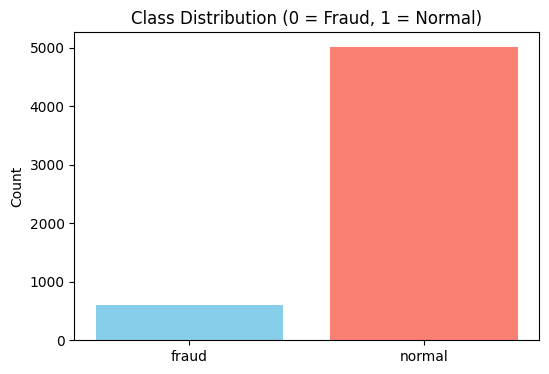

In [280]:
import matplotlib.pyplot as plt

# Count labels
counts = df['label'].value_counts()

# Plot
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=['salmon', 'skyblue'])
plt.xticks(ticks=[0, 1], labels=['fraud', 'normal'])
plt.ylabel("Count")
plt.title("Class Distribution (0 = Fraud, 1 = Normal)")
plt.show()


In [281]:
# Data is imbalanced

In [282]:
import nltk

In [283]:
!pip install nltk

In [284]:
nltk.download('punkt')

# Download the required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4') # This is important for WordNetLemmatizer


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [285]:
from nltk.tokenize import word_tokenize

In [286]:
# num of words
df['num_words'] = df['message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [287]:
df.head()


,label,message,num_words
0,0,"hello, i m bank manager of SBI, ur debit card ...",24
1,0,Todays Vodafone numbers ending with 4882 are s...,27
2,1,Please don't say like that. Hi hi hi,10
3,1,Thank you!,3
4,1,Oh that was a forwarded message. I thought you...,15


In [288]:
df['num_sentences'] = df['message'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [289]:
df.head()

,label,message,num_words,num_sentences
0,0,"hello, i m bank manager of SBI, ur debit card ...",24,1
1,0,Todays Vodafone numbers ending with 4882 are s...,27,2
2,1,Please don't say like that. Hi hi hi,10,2
3,1,Thank you!,3,1
4,1,Oh that was a forwarded message. I thought you...,15,2


In [290]:
df[['num_words','num_sentences']].describe()


,num_words,num_sentences
count,5611.000000,5611.000000
mean,18.090536,1.901800
std,13.150588,1.384849
min,1.000000,1.000000
25%,9.000000,1.000000
50%,14.000000,1.000000
75%,25.000000,2.000000
max,220.000000,38.000000


In [291]:
# normal data label
df[df['label'] == 1][['num_words','num_sentences']].describe()

,num_words,num_sentences
count,5014.000000,5014.000000
mean,17.053251,1.806542
std,13.286158,1.346905
min,1.000000,1.000000
25%,8.000000,1.000000
50%,13.000000,1.000000
75%,22.000000,2.000000
max,220.000000,38.000000


In [292]:
# fraud data label
df[df['label'] == 0][['num_words','num_sentences']].describe()

,num_words,num_sentences
count,597.000000,597.000000
mean,26.802345,2.701843
std,7.616288,1.440619
min,2.000000,1.000000
25%,23.000000,2.000000
50%,28.000000,2.000000
75%,32.000000,3.000000
max,46.000000,9.000000


In [293]:
import seaborn as sns

<Axes: xlabel='num_sentences', ylabel='Count'>

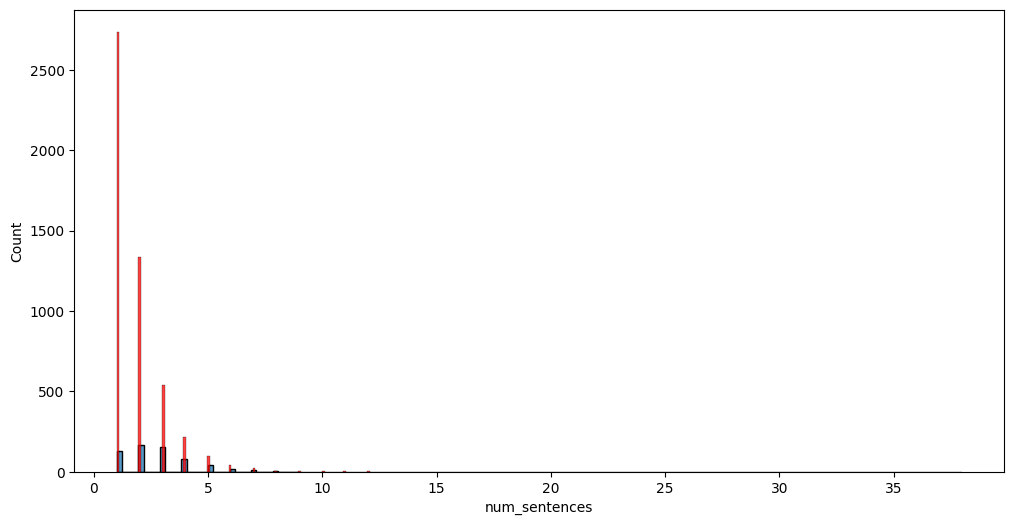

In [294]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label'] == 0]['num_sentences'])
sns.histplot(df[df['label'] == 1]['num_sentences'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

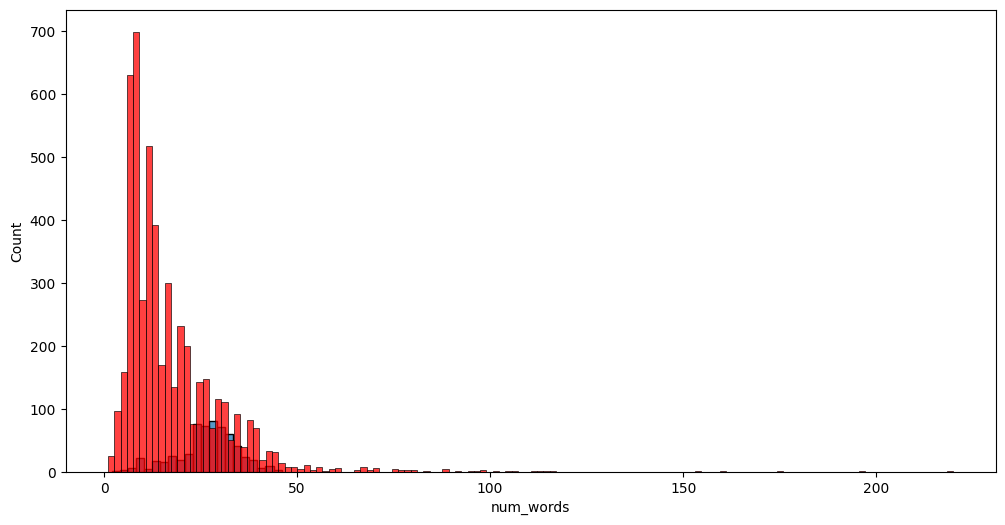

In [295]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label'] == 0]['num_words'])
sns.histplot(df[df['label'] == 1]['num_words'],color='red')

In [296]:
# 3. Data Preprocessing
#1.Lower case
#2.Tokenization
#3.Removing special characters
#4.Removing stop words and punctuation
#5.Stemming

In [297]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [330]:
class PreProcessText(object):
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.stemmer = PorterStemmer()

    def to_lowercase(self, text=''):
        """
        Convert text to lowercase
        """
        return text.lower()

    def remove_punctuation(self, text=''):
        """
        Remove punctuation characters from text
        """
        return ''.join([char for char in text if char not in string.punctuation])

    def remove_stopwords(self, words_list):
        """
        Remove English stopwords from a list of words
        """
        return [word for word in words_list if word not in self.stop_words]

    def stem_words(self, words_list):
        """
        Apply stemming to a list of words
        """
        return [self.stemmer.stem(word) for word in words_list]

    def tokenize(self, text=''):
        """
        Tokenize text into words using NLTK
        """
        return nltk.word_tokenize(text)

    def full_preprocess(self, text=''):
        """
        Complete preprocessing of the texts and Returns a list of processed tokens
        """
        text = self.to_lowercase(text)
        text = self.remove_punctuation(text)
        tokens = self.tokenize(text)
        tokens = self.remove_stopwords(tokens)
        tokens = self.stem_words(tokens)
        return tokens

In [299]:
preprocess=PreProcessText()


In [300]:
# Apply full preprocessing and convert token lists to strings
df['processed_text'] = df['message'].apply(lambda x: " ".join(preprocess.full_preprocess(x)))



In [301]:
df.head()


,label,message,num_words,num_sentences,processed_text
0,0,"hello, i m bank manager of SBI, ur debit card ...",24,1,hello bank manag sbi ur debit card expir would...
1,0,Todays Vodafone numbers ending with 4882 are s...,27,2,today vodafon number end 4882 select receiv £3...
2,1,Please don't say like that. Hi hi hi,10,2,pleas dont say like hi hi hi
3,1,Thank you!,3,1,thank
4,1,Oh that was a forwarded message. I thought you...,15,2,oh forward messag thought send


In [302]:
pip install wordcloud

In [303]:
from wordcloud import WordCloud


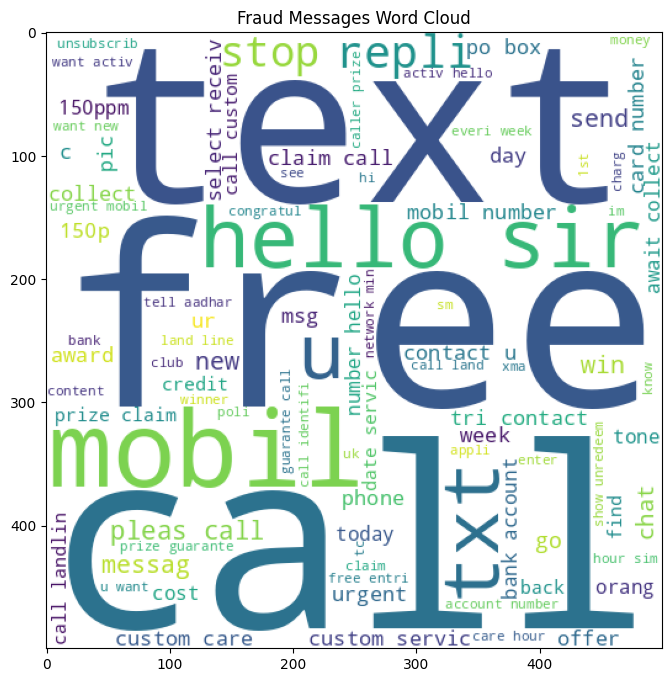

In [304]:
#Fraud messages WordCloud
fraud_text = " ".join(df[df['label'] == 0]['processed_text'])
fraud_wc = WordCloud(
    width=500,
    height=500,
    min_font_size=10,
    background_color='white'
).generate(fraud_text)

plt.figure(figsize=(8,8))
plt.imshow(fraud_wc)
plt.title("Fraud Messages Word Cloud")
plt.show()

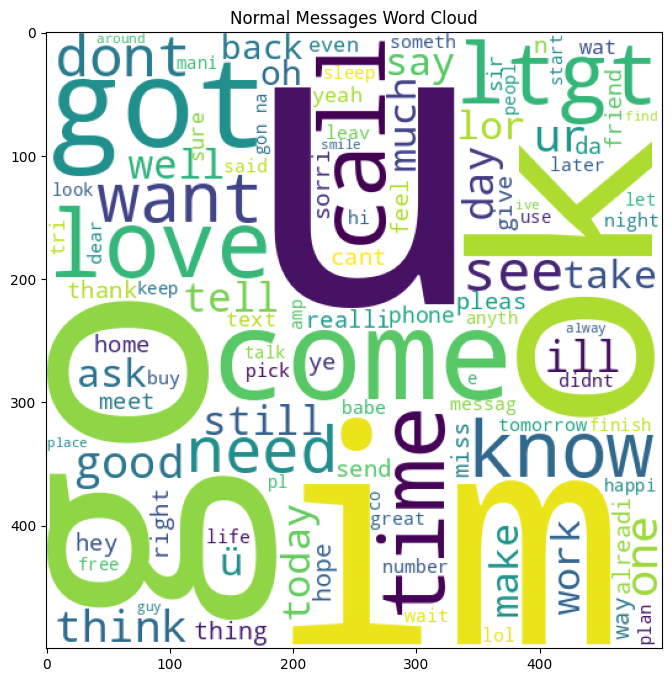

In [305]:
#Normal messages WordCloud

normal_text = " ".join(df[df['label'] == 1]['processed_text'])
normal_wc = WordCloud(
    width=500,
    height=500,
    min_font_size=10,
    background_color='white'
).generate(normal_text)

plt.figure(figsize=(8,8))
plt.imshow(normal_wc)
plt.title("Normal Messages Word Cloud")
plt.show()

In [306]:
df.head()


,label,message,num_words,num_sentences,processed_text
0,0,"hello, i m bank manager of SBI, ur debit card ...",24,1,hello bank manag sbi ur debit card expir would...
1,0,Todays Vodafone numbers ending with 4882 are s...,27,2,today vodafon number end 4882 select receiv £3...
2,1,Please don't say like that. Hi hi hi,10,2,pleas dont say like hi hi hi
3,1,Thank you!,3,1,thank
4,1,Oh that was a forwarded message. I thought you...,15,2,oh forward messag thought send


In [307]:
# Text Vectorization
# Create Bag-of-Words and TF-IDF features
# Bag-of-Words

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer(max_features=3000)
X_bow = cv.fit_transform(df['processed_text']).toarray()

# TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df['processed_text']).toarray()

y = df['label']

In [308]:
# Split data for both

from sklearn.model_selection import train_test_split

# Bag-of-Words split
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=2)

# TF-IDF split
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=2)

In [309]:
#4. Model Building

In [310]:
# Define classifiers

In [311]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

# Initialize classifiers
clfs = {
    'SVC' : SVC(kernel='sigmoid', gamma=1.0),
    'KN' : KNeighborsClassifier(),
    'GNB' : GaussianNB(),
    'MNB': MultinomialNB(),
    'BNB': BernoulliNB(),
    'DT': DecisionTreeClassifier(max_depth=5),
    'LR': LogisticRegression(solver='liblinear', penalty='l1'),
    'RF': RandomForestClassifier(n_estimators=50, random_state=2),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=2),
    'BgC': BaggingClassifier(n_estimators=50, random_state=2),
    'ETC': ExtraTreesClassifier(n_estimators=50, random_state=2),
    'GBDT': GradientBoostingClassifier(n_estimators=50,random_state=2)
}


In [312]:
# Training function

In [313]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision


In [314]:
# Evaluate on Bag-of-Words

In [315]:
accuracy_scores_bow = []
precision_scores_bow = []

for name, clf in clfs.items():
    acc, prec = train_classifier(clf, X_train_bow, y_train, X_test_bow, y_test)
    print(f"Bag-of-Words:  {name}: Accuracy={acc:.4f}, Precision={prec:.4f}")
    accuracy_scores_bow.append(acc)
    precision_scores_bow.append(prec)

# Summary DataFrame
performance_bow = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores_bow,
    'Precision': precision_scores_bow
}).sort_values('Precision', ascending=False)

print(performance_bow)


Bag-of-Words:  SVC: Accuracy=0.9288, Precision=0.9614
Bag-of-Words:  KN: Accuracy=0.9359, Precision=0.9344
Bag-of-Words:  GNB: Accuracy=0.8736, Precision=0.9770
Bag-of-Words:  MNB: Accuracy=0.9715, Precision=0.9881
Bag-of-Words:  BNB: Accuracy=0.9804, Precision=0.9834
Bag-of-Words:  DT: Accuracy=0.9359, Precision=0.9369
Bag-of-Words:  LR: Accuracy=0.9795, Precision=0.9815
Bag-of-Words:  RF: Accuracy=0.9813, Precision=0.9816
Bag-of-Words:  AdaBoost: Accuracy=0.9243, Precision=0.9312
Bag-of-Words:  BgC: Accuracy=0.9706, Precision=0.9795
Bag-of-Words:  ETC: Accuracy=0.9786, Precision=0.9853
Bag-of-Words:  GBDT: Accuracy=0.9581, Precision=0.9591
   Algorithm  Accuracy  Precision
3        MNB  0.971505   0.988060
10       ETC  0.978629   0.985280
4        BNB  0.980410   0.983415
7         RF  0.981300   0.981553
6         LR  0.979519   0.981518
9        BgC  0.970614   0.979452
2        GNB  0.873553   0.976999
0        SVC  0.928762   0.961424
11      GBDT  0.958148   0.959125
5         

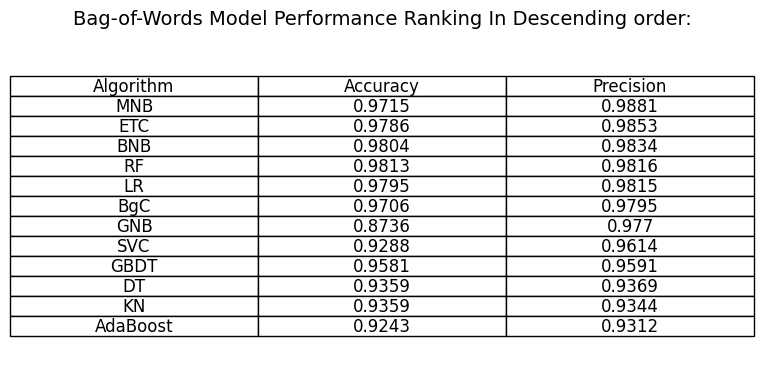

In [316]:
# Bag-of-Words Performance Table
plt.figure(figsize=(8,4))
plt.axis('off')

tbl = plt.table(
    cellText=performance_bow.round(4).values,  # Rounded for readability
    colLabels=performance_bow.columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 1.2)
plt.title("Bag-of-Words Model Performance Ranking In Descending order:", fontsize=14, pad=20)
plt.show()

In [317]:
# Evaluate on TF-IDF

In [318]:
accuracy_scores_tfidf = []
precision_scores_tfidf = []

for name, clf in clfs.items():
    acc, prec = train_classifier(clf, X_train_tfidf, y_train, X_test_tfidf, y_test)
    print(f"TF-IDF:  {name}: Accuracy={acc:.4f}, Precision={prec:.4f}")
    accuracy_scores_tfidf.append(acc)
    precision_scores_tfidf.append(prec)

# Summary DataFrame
performance_tfidf = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores_tfidf,
    'Precision': precision_scores_tfidf
}).sort_values('Precision', ascending=False)

print(performance_tfidf)


TF-IDF:  SVC: Accuracy=0.9804, Precision=0.9834
TF-IDF:  KN: Accuracy=0.9341, Precision=0.9327
TF-IDF:  GNB: Accuracy=0.8691, Precision=0.9727
TF-IDF:  MNB: Accuracy=0.9813, Precision=0.9797
TF-IDF:  BNB: Accuracy=0.9804, Precision=0.9834
TF-IDF:  DT: Accuracy=0.9332, Precision=0.9458
TF-IDF:  LR: Accuracy=0.9599, Precision=0.9636
TF-IDF:  RF: Accuracy=0.9795, Precision=0.9806
TF-IDF:  AdaBoost: Accuracy=0.9163, Precision=0.9331
TF-IDF:  BgC: Accuracy=0.9644, Precision=0.9793
TF-IDF:  ETC: Accuracy=0.9813, Precision=0.9853
TF-IDF:  GBDT: Accuracy=0.9519, Precision=0.9580
   Algorithm  Accuracy  Precision
10       ETC  0.981300   0.985323
0        SVC  0.980410   0.983415
4        BNB  0.980410   0.983415
7         RF  0.979519   0.980583
3        MNB  0.981300   0.979691
9        BgC  0.964381   0.979310
2        GNB  0.869101   0.972707
6         LR  0.959929   0.963602
11      GBDT  0.951915   0.957975
5         DT  0.933215   0.945817
8   AdaBoost  0.916296   0.933082
1         KN  

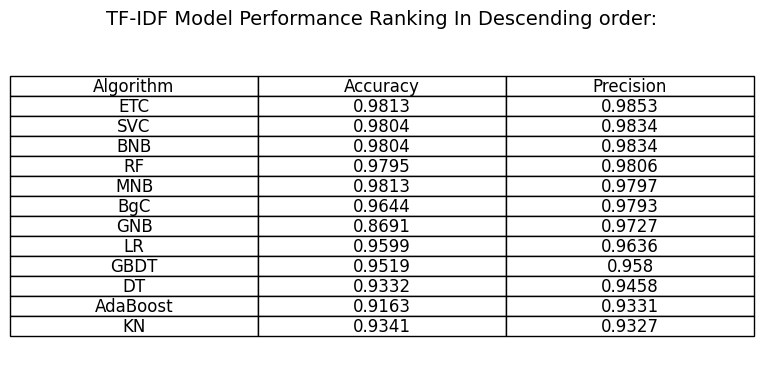

In [319]:
## TF-IDF  Performance Table


plt.figure(figsize=(8,4))
plt.axis('off')

tbl = plt.table(
    cellText=performance_tfidf.round(4).values,
    colLabels=performance_tfidf.columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 1.2)
plt.title("TF-IDF Model Performance Ranking In Descending order:", fontsize=14, pad=20)
plt.show()

## Observation:

1. TF-IDF + ETC has the highest precision overall (0.9853) and very high accuracy (0.9813).

2. Bag-of-Words is also strong, but TF-IDF slightly edges out in overall balance of accuracy + precision.

I chose TF-IDF over Bag-of-Words because Bag-of-Words treats all words equally, giving common words the same importance as critical keywords, which can dilute the signal needed for accurate scam detection. Unlike Bag-of-Words, TF-IDF weighs words according to their importance across the dataset, emphasizing rare but meaningful words that help differentiate scam messages from normal ones. Additionally, My experiments showed that models trained with TF-IDF consistently achieved higher accuracy and precision.

In [320]:
# Retrain model with full preprocessing get it ready to depoly and saving

In [321]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

def print_classification_report(y_true, y_pred, title="Classification Report"):
    report = classification_report(y_true, y_pred, digits=4)
    print(title)
    print(report)

Classification Report (Before SMOTE)
              precision    recall  f1-score   support

           0     0.9897    0.8067    0.8889       119
           1     0.9776    0.9990    0.9882      1004

    accuracy                         0.9786      1123
   macro avg     0.9836    0.9029    0.9385      1123
weighted avg     0.9789    0.9786    0.9777      1123



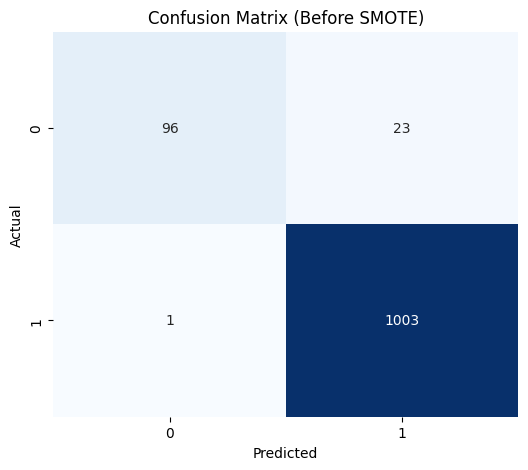

In [322]:
from imblearn.over_sampling import SMOTE

# Preprocess all messages
df['processed_text'] = df['message'].apply(lambda x: " ".join(preprocess.full_preprocess(x)))

# Victorize and each row is a string, safe for TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['processed_text'])
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train ETC
etc = ExtraTreesClassifier(n_estimators=100, random_state=42)

etc.fit(X_train, y_train)  # Train on original imbalanced data
y_pred_before = etc.predict(X_test)

print_classification_report(y_test, y_pred_before, title="Classification Report (Before SMOTE)")
plot_confusion_matrix(y_test, y_pred_before, title="Confusion Matrix (Before SMOTE)")





since SMOTE automatically oversamples the minorty class.and in my dataset

fraud = 0 is minority

normal = 1 is majority

 SMOTE will automatically oversample fraud without the need to spificy anything.

Classification Report (After SMOTE)
              precision    recall  f1-score   support

           0     0.9901    0.8403    0.9091       119
           1     0.9814    0.9990    0.9901      1004

    accuracy                         0.9822      1123
   macro avg     0.9858    0.9197    0.9496      1123
weighted avg     0.9823    0.9822    0.9815      1123



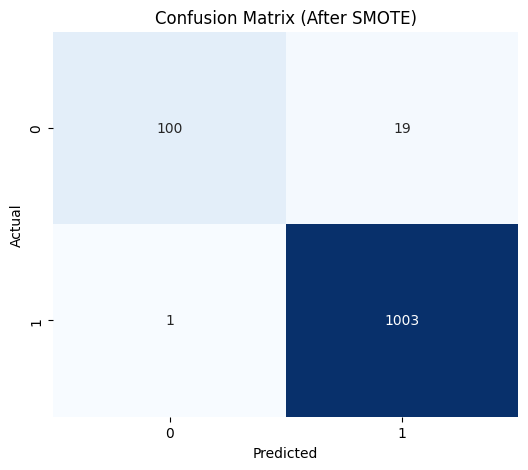

In [323]:

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

etc.fit(X_train_res, y_train_res)
y_pred_after = etc.predict(X_test)

print_classification_report(y_test, y_pred_after, title="Classification Report (After SMOTE)")
plot_confusion_matrix(y_test, y_pred_after, title="Confusion Matrix (After SMOTE)")


##Before SMOTE

1. Class 0 (not scam) recall: 0.8067. The model fails to identify approximately 19% of legitimate messages.

2. Class 1 (scam) recall: 0.9990. Almost all scam messages are correctly detected.

3. Accuracy: 0.9786

4. Weighted F1-score: 0.9777

##After SMOTE

1. Class 0 (not scam) recall: 0.8403. Detection of the minority class has improved.

2. Class 1 (scam) recall: 0.9990. Scam detection remains nearly perfect.

3. Accuracy: 0.9822. Overall accuracy shows a slight improvement.

4. Weighted F1-score: 0.9815. The model demonstrates better balance across classes.

##Interpretation

SMOTE has effectively improved the performance of the minority class (Class 0) by increasing recall from 0.8067 to 0.8403. Precision for both classes remains high, indicating that false positives are still minimal. Overall, the model becomes more balanced and robust while maintaining very high accuracy.

In [324]:
import pickle

# Save TF-IDF vectorizer
with open("tfidf_final.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save trained model (SMOTE-balanced)
with open("etc_model_final.pkl", "wb") as f:
    pickle.dump(etc, f)

print("TF-IDF vectorizer and SMOTE-trained model saved successfully!")


TF-IDF vectorizer and SMOTE-trained model saved successfully!


In [325]:
!pip install googletrans==4.0.0-rc1


In [332]:
scam_keywords = [

    "verify", "identity", "bank account", "unusual activity",
    "frozen", "send info", "send information",
    "prize", "you won", "urgent", "immediately"
]


In [333]:
#Add a scoring function to boost scam probability

def keyword_boost_score(text):
    score = 0
    for kw in scam_keywords:
        if kw.lower() in text.lower():
            score += 1  # each keyword increases risk
    return score


In [338]:
#Combine model prediction with keyword score

def predict_with_boost(message):
    # Translate Arabic to English
    translated = translator.translate(message, src='ar', dest='en').text

    # Preprocess
    tokens = preprocess.full_preprocess(translated)
    processed_str = " ".join(tokens)

    # Vectorize
    vector_input = tfidf.transform([processed_str])
    model_pred = etc.predict(vector_input)[0]  # 0 scam, 1 not scam

    # Calculate keyword score
    boost = keyword_boost_score(translated)

    # Rule-based override
    if boost >= 2:
        final_pred = 0
    else:
        final_pred = model_pred

    return translated, model_pred, boost, final_pred


In [339]:
from googletrans import Translator
import pickle

# Load TF-IDF and trained model
tfidf = pickle.load(open('tfidf_final.pkl', 'rb'))
etc = pickle.load(open('etc_model_final.pkl', 'rb'))

# Light preprocessing class


# Initialize preprocessing
preprocess = PreProcessText()

# Arabic messages examples
messages = [
    # Scam example 1
    "عزيزي العميل، تم اكتشاف نشاط غير معتاد في حسابك البنكي. لتجنب أي قيود، يرجى الاتصال على الرقم 0123456789 وتقديم بياناتك الشخصية الآن.",

    # Scam example 2
    "لقد ربحت للتو جائزة مالية قيمتها 5000 ريال! لتأكيد استلام الجائزة، أرسل رقم حسابك البنكي وكود الهوية في أسرع وقت.",

    # Non-scam example 1
    "مرحباً، نود تذكيرك بالاجتماع الذي سيعقد يوم الأربعاء الساعة الرابعة مساءً. يرجى الحضور في الوقت المحدد.",

    # Non-scam example 2
    "صباح الخير، كيف حالك اليوم؟ لدينا بعض التحديثات على مشروع العمل ونود مناقشتها معك في الاجتماع القادم."
]

for msg in messages:
    translated, model_pred, boost, final_pred = predict_with_boost(msg)

    print("Message:", msg)
    print("Translated:", translated)
    print("Model Prediction:", "Scam" if model_pred == 0 else "Not scam")
    print("Keyword Boost Score:", boost)
    print("Final Prediction:", "Scam" if final_pred == 0 else "Not scam")
    print("-----")

Message: عزيزي العميل، تم اكتشاف نشاط غير معتاد في حسابك البنكي. لتجنب أي قيود، يرجى الاتصال على الرقم 0123456789 وتقديم بياناتك الشخصية الآن.
Translated: Dear customer, unusual activity has been detected in your bank account.To avoid any restrictions, please call 0123456789 and provide your personal data now.
Model Prediction: Not scam
Keyword Boost Score: 2
Final Prediction: Scam
-----
Message: لقد ربحت للتو جائزة مالية قيمتها 5000 ريال! لتأكيد استلام الجائزة، أرسل رقم حسابك البنكي وكود الهوية في أسرع وقت.
Translated: You just won a cash prize worth 5000 riyals!To confirm receipt of the prize, send your bank account number and ID code as soon as possible.
Model Prediction: Scam
Keyword Boost Score: 2
Final Prediction: Scam
-----
Message: مرحباً، نود تذكيرك بالاجتماع الذي سيعقد يوم الأربعاء الساعة الرابعة مساءً. يرجى الحضور في الوقت المحدد.
Translated: Hello, We would like to remind you of the meeting that will be held on Wednesday at 4 p.m.Please arrive on time.
Model Prediction: Not